## Model Training and Pipeline 
This notebook builds and compares the regression models to predict apartment prices in Poland using May-June 2024 data. 

The workflow includes the following **Steps:**
1. Load cleaned data and apply encoding to categorical variables 
2. Remove correlated features identified in EDA 
3. Train and compare three models : Linear regression, Decision Tree, Random Forest 
4. Hyperparameter tuning using ```GridSearchCV```
5. Create sklearn Pipeline combining preprocessing + best fit model
6. Serialize pipeline and feature names for Flask deployment 

**Outputs:**
- `housing_model.pkl`-Complete pipeline (preprocessing + model)
- `feature_names.json`- required input features for validation 


In [10]:
#importing all the necessary libraries  
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import pickle
import json
from custom_classes import CustomePreprocess
%matplotlib inline

In [270]:
df=pd.read_csv("Cleaned_data_Polish_housing.csv", sep=",")
df.head()

,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,...,restaurantDistance,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,blockOfFlats,47.00,2.0,6.0,12.0,1981.0,53.428544,14.552812,0.79,67.0,...,0.068,0.593,0.085,condominium,no,yes,yes,no,yes,449000
1,apartmentBuilding,88.22,3.0,1.0,2.0,2000.0,53.449093,14.516844,4.09,0.0,...,0.661,1.192,0.668,condominium,yes,yes,no,no,no,950000
2,blockOfFlats,33.31,1.0,1.0,4.0,1963.0,53.436100,14.541200,1.93,39.0,...,0.180,0.041,0.388,cooperative,yes,no,no,yes,yes,380000
3,blockOfFlats,56.00,3.0,7.0,7.0,2018.0,53.447465,14.557811,2.68,10.0,...,0.322,1.643,0.178,condominium,yes,yes,yes,yes,yes,799000
4,blockOfFlats,68.61,3.0,4.0,4.0,1997.0,53.456213,14.583222,3.94,7.0,...,0.071,0.786,0.304,condominium,no,yes,no,no,yes,599000


In [271]:
df.columns

Index(['type', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
       'latitude', 'longitude', 'centreDistance', 'poiCount', 'schoolDistance',
       'clinicDistance', 'postOfficeDistance', 'kindergartenDistance',
       'restaurantDistance', 'collegeDistance', 'pharmacyDistance',
       'ownership', 'hasParkingSpace', 'hasBalcony', 'hasElevator',
       'hasSecurity', 'hasStorageRoom', 'price'],
      dtype='str')

In [272]:
# We upload the list from EDA project of the binary and categorical features to be encoded. 
Binary_cat_list=['hasParkingSpace','hasBalcony','hasElevator','hasSecurity','hasStorageRoom']
Mult_cat_list=['type','ownership']

In [273]:
# Encoding the categorical features using OneHotEncoder for multi-class categorical features and OrdinalEncoder for binary categorical features.
df_transformed=df.copy()
oe=OrdinalEncoder()                                 
for name in Binary_cat_list:
   df_transformed[[name]]=oe.fit_transform(df_transformed[[name]])


ct=ColumnTransformer(transformers=[("encoder", OneHotEncoder(), Mult_cat_list)], remainder="passthrough")
Transformed_array=ct.fit_transform(df_transformed)
column_names=ct.get_feature_names_out()
df_transformed=pd.DataFrame(Transformed_array, columns=column_names, index=df_transformed.index)


# Cleaning the column names to remove the prefix added by OneHotEncoder and OrdinalEncoder
df_transformed.columns=df_transformed.columns.str.removeprefix("encoder__")
df_transformed.columns=df_transformed.columns.str.removeprefix("remainder__")

In [274]:
# Drop the columns with multicollinearity based on the correlation matrix from EDA project. 
To_remove=['type_tenement','kindergartenDistance','rooms','ownership_cooperative','floor','type_apartmentBuilding','postOfficeDistance','pharmacyDistance','schoolDistance']
df_transformed.drop(columns=To_remove, inplace=True)

In [275]:
# Creating the X and y variables for the model training and testing.
X=df_transformed.iloc[:, :-1]
y=df_transformed.iloc[:, -1]

In [276]:
X.columns

Index(['type_blockOfFlats', 'ownership_condominium', 'ownership_udział',
       'squareMeters', 'floorCount', 'buildYear', 'latitude', 'longitude',
       'centreDistance', 'poiCount', 'clinicDistance', 'restaurantDistance',
       'collegeDistance', 'hasParkingSpace', 'hasBalcony', 'hasElevator',
       'hasSecurity', 'hasStorageRoom'],
      dtype='str')

In [277]:
X

,type_blockOfFlats,ownership_condominium,ownership_udział,squareMeters,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,clinicDistance,restaurantDistance,collegeDistance,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
0,1.0,1.0,0.0,47.00,12.0,1981.0,53.428544,14.552812,0.79,67.0,0.285,0.068,0.593,0.0,1.0,1.0,0.0,1.0
1,0.0,1.0,0.0,88.22,2.0,2000.0,53.449093,14.516844,4.09,0.0,1.039,0.661,1.192,1.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,33.31,4.0,1963.0,53.436100,14.541200,1.93,39.0,0.326,0.180,0.041,1.0,0.0,0.0,1.0,1.0
3,1.0,1.0,0.0,56.00,7.0,2018.0,53.447465,14.557811,2.68,10.0,0.771,0.322,1.643,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,0.0,68.61,4.0,1997.0,53.456213,14.583222,3.94,7.0,1.336,0.071,0.786,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23166,0.0,1.0,0.0,58.97,19.0,2020.0,53.126000,18.007900,0.65,54.0,0.205,0.058,0.622,1.0,1.0,1.0,0.0,0.0
23167,0.0,1.0,0.0,95.00,3.0,1893.0,53.126000,18.007900,0.65,54.0,0.205,0.058,0.622,0.0,0.0,0.0,0.0,1.0
23168,0.0,1.0,0.0,87.00,3.0,1908.0,53.127340,17.988540,1.01,13.0,1.122,0.437,0.386,0.0,0.0,0.0,0.0,1.0
23169,0.0,1.0,0.0,108.96,4.0,1889.0,53.131748,18.000648,1.08,28.0,0.792,0.107,0.226,0.0,0.0,0.0,0.0,1.0


In [278]:
y

0        449000.0
1        950000.0
2        380000.0
3        799000.0
4        599000.0
           ...   
23166    678155.0
23167    599000.0
23168    509000.0
23169    795000.0
23170    300000.0
Name: price, Length: 23171, dtype: float64

In [279]:
# Splitting the data into training and testing sets. 
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=0)

In [280]:
X_train

,type_blockOfFlats,ownership_condominium,ownership_udział,squareMeters,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,clinicDistance,restaurantDistance,collegeDistance,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
14718,1.0,0.0,0.0,71.80,5.0,1995.0,53.115358,23.143413,2.00,14.0,0.782,0.162,1.568,0.0,1.0,0.0,0.0,1.0
11826,1.0,1.0,0.0,52.00,5.0,2023.0,53.130770,17.977059,1.86,5.0,1.048,0.550,0.335,0.0,1.0,1.0,0.0,0.0
21764,1.0,1.0,0.0,38.00,4.0,1973.0,52.225008,21.071111,4.66,14.0,1.165,0.184,0.503,0.0,1.0,0.0,0.0,1.0
10384,0.0,1.0,0.0,94.00,8.0,2007.0,52.132500,21.074600,12.05,23.0,0.275,0.185,0.666,1.0,1.0,1.0,1.0,0.0
7153,1.0,1.0,0.0,84.10,4.0,1987.0,51.273136,22.544916,3.25,9.0,1.498,0.082,0.893,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,0.0,1.0,0.0,64.00,1.0,1936.0,50.071098,19.923965,2.04,18.0,0.504,0.059,0.591,0.0,1.0,1.0,0.0,0.0
19648,0.0,1.0,0.0,25.50,1.0,1932.0,52.221640,21.145050,9.70,5.0,2.531,0.631,3.200,0.0,1.0,0.0,0.0,0.0
9845,1.0,1.0,0.0,37.50,10.0,1967.0,52.246860,21.096390,6.54,19.0,0.543,0.299,1.051,0.0,1.0,1.0,0.0,1.0
10799,1.0,1.0,0.0,42.00,4.0,2023.0,52.154140,21.084100,10.22,7.0,1.964,0.104,1.893,0.0,1.0,1.0,1.0,0.0


In [281]:
X_test

,type_blockOfFlats,ownership_condominium,ownership_udział,squareMeters,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,clinicDistance,restaurantDistance,collegeDistance,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
644,0.0,1.0,0.0,74.00,3.0,2015.0,54.511270,18.544770,1.14,34.0,0.547,0.183,0.623,0.0,1.0,1.0,0.0,1.0
19551,0.0,1.0,0.0,66.40,2.0,1936.0,52.159500,21.203400,15.81,7.0,0.746,0.390,1.893,0.0,0.0,0.0,0.0,0.0
8059,0.0,1.0,0.0,48.92,6.0,2020.0,52.258110,20.969580,3.74,33.0,0.216,0.020,0.651,0.0,0.0,1.0,1.0,0.0
845,0.0,1.0,0.0,85.50,7.0,2023.0,50.023625,19.962105,3.91,5.0,0.777,0.130,1.941,1.0,1.0,1.0,0.0,0.0
19732,1.0,1.0,0.0,26.50,4.0,1972.0,52.296170,21.043250,7.66,20.0,0.648,0.378,2.449,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17671,0.0,0.0,0.0,96.40,4.0,1930.0,51.769900,19.483700,2.37,6.0,0.642,0.536,0.595,0.0,1.0,0.0,0.0,0.0
2739,1.0,1.0,0.0,50.00,11.0,1980.0,52.387400,16.861700,5.51,9.0,0.652,0.338,0.997,0.0,1.0,1.0,0.0,1.0
10062,1.0,1.0,0.0,33.14,4.0,1951.0,52.246795,20.994014,1.80,39.0,0.490,0.173,0.108,0.0,0.0,0.0,0.0,1.0
19367,1.0,1.0,0.0,64.00,10.0,1970.0,52.200000,21.023200,3.77,34.0,0.323,0.027,1.028,0.0,1.0,1.0,0.0,1.0


In [282]:
y_train

14718     609000.0
11826     625000.0
21764     775000.0
10384    1750000.0
7153      649000.0
           ...    
13123    1290000.0
19648     550000.0
9845      650000.0
10799     919000.0
2732      999000.0
Name: price, Length: 18536, dtype: float64

In [283]:
y_test

644      2100000.0
19551     930000.0
8059     1300000.0
845      1624000.0
19732     535000.0
           ...    
17671     910000.0
2739      465000.0
10062     660000.0
19367     949000.0
14510     820000.0
Name: price, Length: 4635, dtype: float64

# Multiple Linear Regression Model 
We create the multiple regression model and check the metrics. 

In [284]:
# Creating and training the Linear Regression model.
regressor=LinearRegression()
regressor.fit(X_train, y_train)
y_pred=regressor.predict(X_test)

In [285]:
# Checking R2 Score 
R2_score=r2_score(y_test, y_pred)
R2_score_train=r2_score(y_train, regressor.predict(X_train))
MAE=mean_absolute_error(y_test, y_pred)
print("R2 Score:", R2_score)
print("Training R2 score:", R2_score_train)
print("Mean Absolute Error:", MAE)

R2 Score: 0.666783699304518
Training R2 score: 0.6634004725239442
Mean Absolute Error: 186175.11256134213


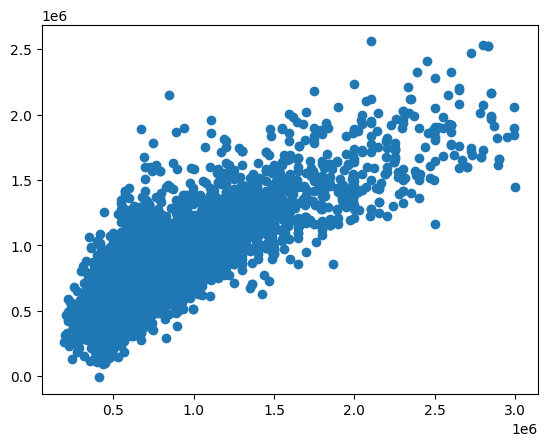

In [286]:
# Plotting y_test vs y_pred to visualize the performance of the model.
plt.scatter(y_test, y_pred)

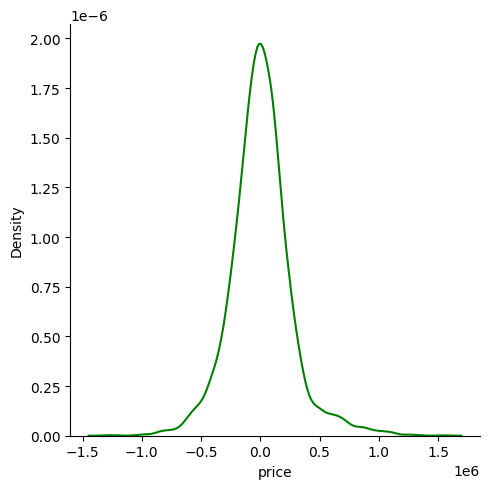

In [287]:
# Checking using residuals to see if the model is performing well. 
# The residuals should be normally distributed around zero if the model is performing well.
residuals=y_test-y_pred
sns.displot(residuals, kind="kde", color="g")

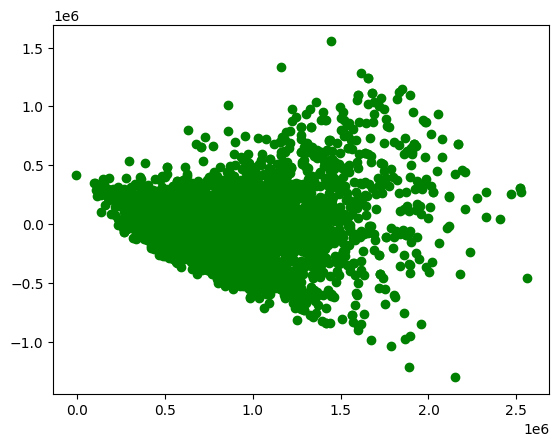

In [288]:
plt.scatter(y_pred, residuals, color="g")

#### Because the linear regression model achieved a limited $R^2$ score, we evaluate a Decision Tree Regressor to determine whether it can better capture nonlinear relationships in the data.

# Decision Tree

In [289]:
# Building and training the Decision Tree Regression model.
regressor_tree=DecisionTreeRegressor()
regressor_tree.fit(X_train, y_train)
y_pred=regressor_tree.predict(X_test)

In [290]:
#Evaluating the decision tree model 
R2_score=r2_score(y_test, y_pred)
R2_score_train=r2_score(y_train, regressor_tree.predict(X_train))
MAE=mean_absolute_error(y_test, y_pred)
print("R2 Score:", R2_score)
print("Training R2 score:", R2_score_train)
print("Mean Absolute Error:", MAE)

R2 Score: 0.9129781639429072
Training R2 score: 0.9995890996394844
Mean Absolute Error: 59555.489140596896


#### The decision tree shows signs of overfitting: its training $R^2$ score is exceptionally high (0.9996), while the test $R^2$ score is lower (0.9144). This indicates that the model fits the training data very closely but generalizes less effectively to unseen data.

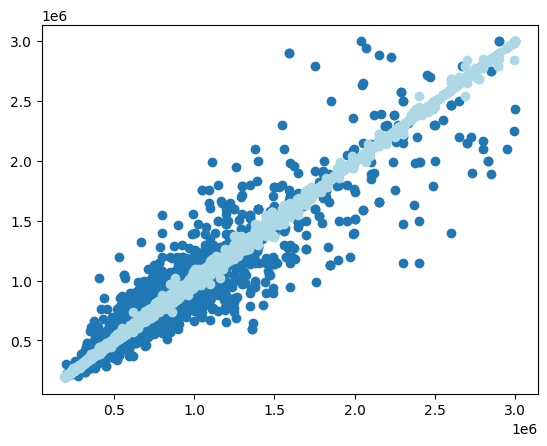

In [291]:
# This could also be visually cofirmed by plotting the y_test vs y_pred  and y_train vs y_pred to see how well the model is performing.
plt.scatter(y_test, y_pred)
plt.scatter(y_train, regressor_tree.predict(X_train), color="lightblue")

# Random Forest 
To build Random Forest, we perform ```GridSearchCV``` to identify the optimal hyperparameters.

In [292]:
parameters= {'n_estimators': [100, 200], 'min_samples_leaf': [1,4,8,], 'max_depth': [5, 10], "min_samples_split":[10, 20], "max_features":["sqrt", 0.5]}
grid_search=GridSearchCV(estimator=RandomForestRegressor(), 
                         param_grid=parameters, 
                         cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 4, ...], 'min_samples_split': [10, 20], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [293]:
# grid_search=RandomForestRegressor(max_depth=10, max_features=0.5, min_samples_split=5,
#                       n_estimators=200, min_samples_leaf=4)
# grid_search.fit(X_train, y_train)

In [294]:
y_pred=grid_search.predict(X_test)

In [295]:
print(grid_search.best_score_)
print(grid_search.best_estimator_)

0.9089519487713267
RandomForestRegressor(max_depth=10, max_features=0.5, min_samples_split=10,
                      n_estimators=200)


In [296]:
R2_score=r2_score(y_test, y_pred)
R2_score_train=r2_score(y_train, grid_search.predict(X_train))
MAE=mean_absolute_error(y_test, y_pred)
print("R2 Score:", R2_score)
print("Training R2 score:", R2_score_train)
print("Mean Absolute Error:", MAE)

R2 Score: 0.9132552017527495
Training R2 score: 0.9419984429584427
Mean Absolute Error: 88679.29016636488


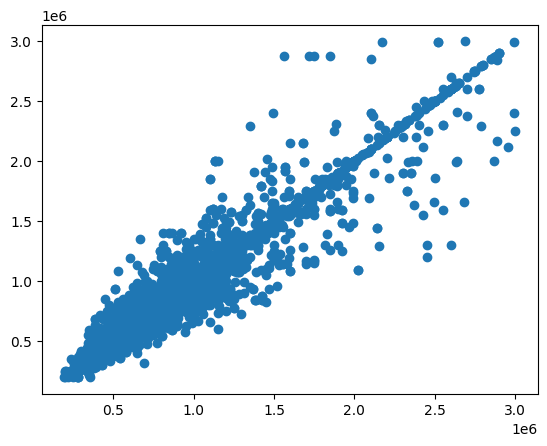

In [ ]:
plt.scatter(y_test, y_pred)

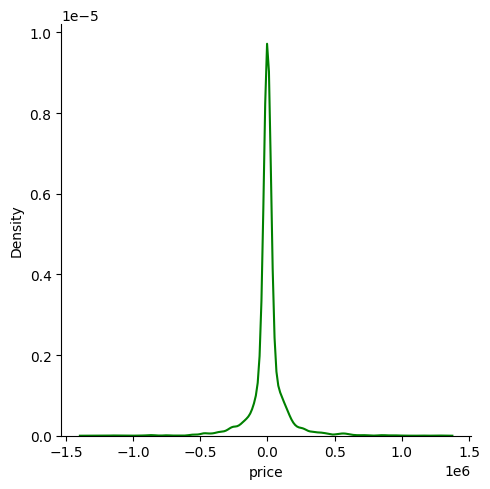

In [ ]:
# Residual distribution plot he model is performing well  
residuals=y_test-y_pred
sns.displot(residuals, kind="kde", color="g")

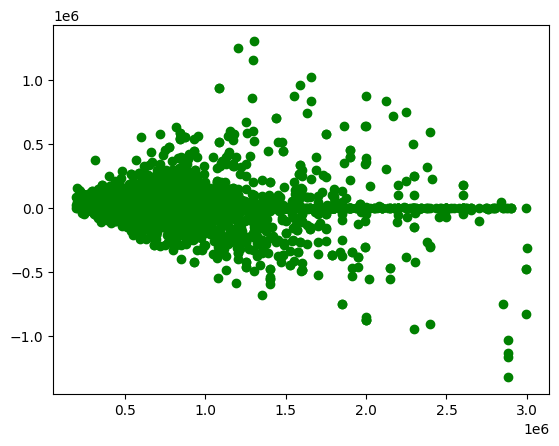

In [ ]:
plt.scatter(y_pred, residuals, color="g")

### CustomPreprocess: Encodes categorical features and drops correlated columns
#### Wraps all preprocessing steps into a sklearn-compatible transformer 
#### so it can be used as a Pipeline step alongside the model.

In [11]:
df=pd.read_csv("Cleaned_data_Polish_housing.csv")
X=df.iloc[:, :-1]
y=df.iloc[:, -1]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

#### We created a preprocessing class which encodes and drops the correlated columns in the fil ```custom_classes```. 
#### Here we import it and provide it as a transformer to the pipeline

In [ ]:
# Creating the pipeline for encoding and modelling
# Use the class CustomeProcess from custom_classes.py which we created

pipeline=Pipeline(
    steps=[("preprocessor", CustomePreprocess(Binary_cat_list=Binary_cat_list, Mult_cat_list=Mult_cat_list, To_remove=To_remove)), 
           ("model", RandomForestRegressor(max_depth=10, max_features=0.5,
                      min_samples_split=10, n_estimators=200) )])
pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,Binary_cat_list,"['hasParkingSpace', 'hasBalcony', ...]"
,Mult_cat_list,"['type', 'ownership']"
,To_remove,"['type_tenement', 'kindergartenDistance', ...]"
Name,Type,Value
ct_,ColumnTransformer,ColumnTransfo...ownership'])])
oe_,OrdinalEncoder,OrdinalEncoder()
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200


In [14]:
y_pred=pipeline.predict(X_test)
r2_score(y_test, y_pred)

0.9184601117062061

In [15]:
# Pickle the pipeline 
pickle.dump(pipeline, open("housing_model.pkl", "wb"))


In [16]:
# Saving the feature names required in data frame as json file 
feature_names=list(df.columns)
json.dump(feature_names, open("feature_names.json", "w"))


In [17]:
test_record = pd.DataFrame([{
    'type':                 'blockOfFlats',
    'squareMeters':          55,
    'rooms':                 3,             
    'floor':                 2,             
    'floorCount':            5,
    'buildYear':             2005,
    'latitude':              52.2297,
    'longitude':             21.0122,
    'centreDistance':        3.5,
    'poiCount':              50,
    'schoolDistance':        0.5,           
    'clinicDistance':        0.8,
    'postOfficeDistance':    1.0,           
    'kindergartenDistance':  0.4,           
    'restaurantDistance':    0.3,
    'collegeDistance':       1.2,
    'pharmacyDistance':      0.6,           
    'ownership':            'condominium',
    'hasParkingSpace':      'yes',
    'hasBalcony':           'yes',
    'hasElevator':          'yes',
    'hasSecurity':          'no',
    'hasStorageRoom':       'no'
}])
pipeline.predict(test_record)


array([1042045.1031971])